# 08 — Kalibrasi LLM Judge oleh Anotasi Manual

Artefak untuk pertanyaan reviewer: **"bagaimana Anda tahu filter Anda bekerja?"**

Judge di `judge_quality.py` membuang baris dari data latih. Sebelum dilepas ke 2.336 baris,
vonisnya diadu dulu dengan 22 anotasi manual pada sampel 260 baris (`seed=7`) yang tersimpan
sebagai kode di `src/data_validation/calibration_labels.py`.

Notebook ini **tipis**: semua logika ada di `src/`, di sini hanya pemanggilan + visualisasi.

- `src/preprop/clean_easy_v2.py` — bangun ulang `easy_clean_v2.jsonl` (deterministik, CPU)
- `src/data_validation/calibration_labels.py` — label manual
- `src/data_validation/calibrate_judge.py` — Wilson CI, presisi/recall, laporan

**Batas sahih dibaca lebih dulu, bukan belakangan** — lihat sel terakhir.

In [1]:
import os, sys
p = os.getcwd()
while not os.path.isdir(os.path.join(p, 'src')) and os.path.dirname(p) != p:
    p = os.path.dirname(p)
os.chdir(p); sys.path.insert(0, p)

import matplotlib.pyplot as plt
from pathlib import Path

from src.preprop import clean_easy_v2
from src.data_validation import calibration_labels as labels
from src.data_validation import calibrate_judge as cal

print('repo root:', p)

repo root: /home/jeremy-mboe/Documents/Kuliah/Sem4/GemastikDataMining/nlp/FP_NLP


## 1. Bangun ulang `easy_clean_v2.jsonl`

`data/*` masuk `.gitignore` kecuali `data/Final/*_v3.*`, jadi berkas v2 tidak ikut ter-commit dan
pernah hilang — memutus kalibrasi karena indeks anotasi menunjuk sampel dari berkas itu.
Regenerasi di sini deterministik; angkanya wajib sama dengan notebook 07.

In [2]:
stats = clean_easy_v2.run()
for k, v in stats.items():
    print(f'{k:14}: {v}')

assert stats['input'] == clean_easy_v2.ACUAN_INPUT, stats['input']
assert stats['bersih'] == clean_easy_v2.ACUAN_KEEP_TOTAL, stats['bersih']
for alasan, n in clean_easy_v2.ACUAN_ALASAN.items():
    assert stats['alasan'][alasan] == n, (alasan, stats['alasan'][alasan], n)
print('\ncocok dengan acuan notebook 07: 2.686 -> 2.336, '
      'bare_letter 278, REPAIR 107, english 50, fabricated 22')

input         : 2686
bersih        : 2336
dibuang       : 350
alasan        : {'KEEP': 2229, 'jawaban_bare_letter': 278, 'REPAIR': 107, 'cara_fabricated': 22, 'english_leak': 50}
output_path   : data/Final/easy_clean_v2.jsonl
dropped_path  : data/Final/easy_clean_v2_dropped.jsonl

cocok dengan acuan notebook 07: 2.686 -> 2.336, bare_letter 278, REPAIR 107, english 50, fabricated 22


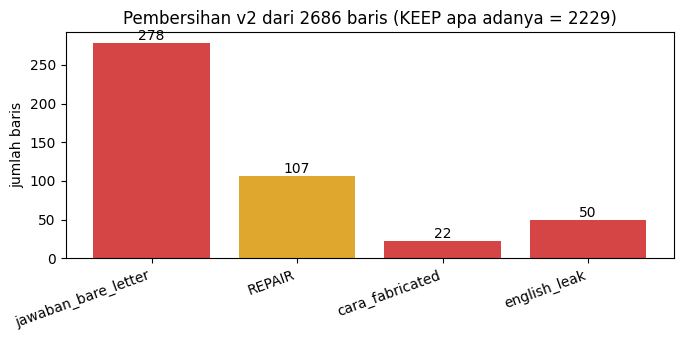

In [3]:
# Visualisasi 1: apa yang dibuang saat membangun v2
alasan = {k: v for k, v in stats['alasan'].items() if k != 'KEEP'}
warna = ['#e0a72e' if k == 'REPAIR' else '#d64545' for k in alasan]

plt.figure(figsize=(7, 3.5))
bar = plt.bar(list(alasan), list(alasan.values()), color=warna)
plt.ylabel('jumlah baris')
plt.title(f"Pembersihan v2 dari {stats['input']} baris (KEEP apa adanya = {stats['alasan']['KEEP']})")
plt.xticks(rotation=20, ha='right')
for b, c in zip(bar, alasan.values()):
    plt.text(b.get_x() + b.get_width() / 2, c, str(c), ha='center', va='bottom')
plt.tight_layout(); plt.show()

## 2. Sampel kalibrasi dan sebaran anotasi manual

Sampel dibentuk ulang persis seperti `judge_quality.run(--limit 260 --seed 7)`: `_idx` dipasang
dulu, baru `random.Random(7).sample`. Indeks di `calibration_labels.py` 0-indexed terhadap
**sampel**, bukan terhadap berkas.

In [4]:
sampel = labels.sampel_kalibrasi('data/Final/easy_clean_v2.jsonl')
print(f'sampel: {len(sampel)} baris, seed={labels.SEED}')

for nama, idxs in labels.KATEGORI.items():
    print(f'{nama:14} n={len(idxs):2d}  {idxs}')
print()
print(f'Q1_POSITIF (acuan recall Q1) : {labels.Q1_POSITIF}  -> n={len(labels.Q1_POSITIF)}')
print(f'Q2_POSITIF (pasti)           : {labels.Q2_POSITIF}')
print(f'Q2_POSITIF_RAGU (belum pasti): {labels.Q2_POSITIF_RAGU}')

sampel: 260 baris, seed=7
C1_FABRIKASI   n= 7  [53, 108, 111, 140, 203, 215, 220]
C2_KORUPSI     n= 3  [25, 144, 222]
C3_MISMATCH    n= 4  [164, 187, 169, 190]
C4_BLEED       n= 4  [48, 80, 230, 254]
C5_CARA_ENG    n= 4  [58, 103, 124, 207]

Q1_POSITIF (acuan recall Q1) : [25, 53, 108, 111, 140, 144, 203, 215, 220, 222]  -> n=10
Q2_POSITIF (pasti)           : [108]
Q2_POSITIF_RAGU (belum pasti): [111, 207]


In [5]:
# Contoh nyata tiap kategori — biar anotasi bisa diperiksa mata, bukan dipercaya begitu saja
for nama, idxs in labels.KATEGORI.items():
    r = sampel[idxs[0]]
    print(f'[{nama}] idx {idxs[0]}')
    print(f'   soal   : {str(r.get("soal", ""))[:150]!r}')
    print(f'   jawaban: {str(r.get("jawaban", ""))[:80]!r}\n')

[C1_FABRIKASI] idx 53
   soal   : 'Gunakan sifat segiempat talibusur.'
   jawaban: '96'

[C2_KORUPSI] idx 25
   soal   : 'Solusi bilangan bulat untuk pertidaksamaan $& \\le 8 - 16$ ada sebanyak?'
   jawaban: 'Jadi ada 2 yaitu $x = -2$ dan $x = 2$'

[C3_MISMATCH] idx 164
   soal   : 'Bayangan titik A(5, 7) oleh translasi $\\begin{pmatrix} 2 \\\\ 3 \\end{pmatrix}$ dan dilanjutkan $\\begin{pmatrix} 4 \\\\ -1 \\end{pmatrix}$ adalah ...'
   jawaban: '(7, 8)'

[C4_BLEED] idx 48
   soal   : 'Misalkan $a, b, c, d$, dan $e$ adalah bilangan-bilangan bulat sehingga $2^a 3^b 4^c 5^d 6^e$ juga merupakan bilangan bulat. Jika diketahui bahwa nilai'
   jawaban: '-2012'

[C5_CARA_ENG] idx 58
   soal   : 'Hitunglah sudut tajam diantara permukaan $xy^2z = 3x + z^2$ dan $3x^2 - y^2 + 2z = 1$ pada titik $(1, -2, 1)$.'
   jawaban: '$\\arccos \\frac{3}{\\sqrt{14}\\sqrt{21}} = \\arccos \\frac{\\sqrt{6}}{14} = 79^\\circ 5'



## 3. Tahap A (regex) pada sampel yang sama

Konteks sebelum menilai judge: sebagian baris rusak sudah tersaring aturan deterministik, jadi
judge tidak pernah melihatnya. Angka ini menjelaskan kenapa recall judge saja bukan gambaran
utuh performa filter.

In [6]:
stage = cal.ringkas_stage_a(sampel)
print(f"tahap A membuang {stage['n_drop']} dari {len(sampel)} baris sampel")
print(f"tumpang tindih dengan positif manual Q1: {stage['tumpang_tindih_q1']} "
      f"({len(stage['tumpang_tindih_q1'])} dari {len(labels.Q1_POSITIF)})")

from collections import Counter
for a, n in Counter(stage['alasan'].values()).most_common():
    print(f'  {a:24s} {n:3d}')

tahap A membuang 9 dari 260 baris sampel
tumpang tindih dengan positif manual Q1: [] (0 dari 10)
  butuh_gambar               9


## 4. Aritmetika presisi/recall + Wilson

Interval Wilson dipakai, bukan Wald: n di sini 10, dan proporsinya dekat 0/1 — dua kondisi yang
membuat Wald melenceng bahkan keluar dari [0, 1]. Sel di bawah menjalankan `--self-check`
modulnya (vonis palsu) supaya aritmetikanya terverifikasi di dalam notebook, bukan cuma di CLI.

In [7]:
cal.self_check()

self-check OK: 6 kasus Wilson, 4 kasus metrik, 1 jalur evaluasi penuh (vonis palsu), 9 kasus bentuk jawaban, 1 tabel silang
  contoh: recall Q1 7/10 = 0,700 dengan CI95 Wilson [0.397, 0.892] -> lebar 50 poin persen


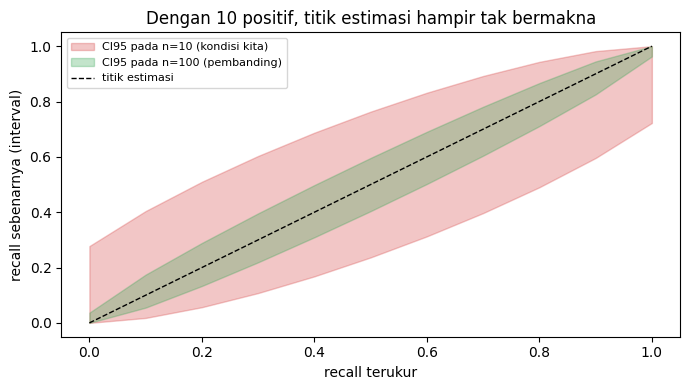

recall 5/10 = 0.500  CI95 [0.237, 0.763]  lebar 53 pp
recall 7/10 = 0.700  CI95 [0.397, 0.892]  lebar 50 pp
recall 9/10 = 0.900  CI95 [0.596, 0.982]  lebar 39 pp
recall 10/10 = 1.000  CI95 [0.722, 1.000]  lebar 28 pp


In [8]:
# Visualisasi 2: seberapa lebar CI recall kalau acuan cuma 10 positif
n_acuan = len(labels.Q1_POSITIF)
titik = [k / n_acuan for k in range(n_acuan + 1)]
lo = [cal.wilson_ci(k, n_acuan)[0] for k in range(n_acuan + 1)]
hi = [cal.wilson_ci(k, n_acuan)[1] for k in range(n_acuan + 1)]
lo100 = [cal.wilson_ci(round(t * 100), 100)[0] for t in titik]
hi100 = [cal.wilson_ci(round(t * 100), 100)[1] for t in titik]

plt.figure(figsize=(7, 4))
plt.fill_between(titik, lo, hi, alpha=.3, color='#d64545',
                 label=f'CI95 pada n={n_acuan} (kondisi kita)')
plt.fill_between(titik, lo100, hi100, alpha=.3, color='#3aa655',
                 label='CI95 pada n=100 (pembanding)')
plt.plot(titik, titik, 'k--', lw=1, label='titik estimasi')
plt.xlabel('recall terukur'); plt.ylabel('recall sebenarnya (interval)')
plt.title('Dengan 10 positif, titik estimasi hampir tak bermakna')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

for k in (5, 7, 9, 10):
    a, b = cal.wilson_ci(k, n_acuan)
    print(f'recall {k}/{n_acuan} = {k/n_acuan:.3f}  CI95 [{a:.3f}, {b:.3f}]  lebar {100*(b-a):.0f} pp')

## 5. Vonis judge

Sel di bawah membaca berkas `.progress` hasil `run_judge`. Kalau belum ada, ia berhenti dan
mengatakannya, **bukan** mengarang angka.

Vonis yang dibaca di sini dihasilkan di Kaggle 2xT4 dengan judge produksi
`Qwen/Qwen2.5-7B-Instruct` pada 260 sampel `seed=7` (260 vonis Q1 + 260 Q2). Runner-nya:
`notebooks/kaggle/kalibrasi_judge_kaggle.ipynb`.

```bash
# jalankan ulang kalau label kalibrasi berubah
python -m src.data_validation.calibrate_judge --judge-backend vllm --tensor-parallel-size 2
```

In [9]:
OUT = Path('reports/kalibrasi_judge')
prog_q1, prog_q2 = OUT / 'kalibrasi_q1.progress', OUT / 'kalibrasi_q2.progress'

if not (prog_q1.exists() and prog_q2.exists()):
    print('BELUM ADA VONIS JUDGE.')
    print(f'  dicari di: {prog_q1} dan {prog_q2}')
    print()
    print('Presisi/recall Q1 dan Q2 TIDAK dapat dilaporkan dari notebook ini.')
    print('Issue #3 tetap terblokir sampai perintah di sel markdown atas dijalankan')
    print('di mesin ber-GPU dengan judge produksi.')
    hasil = None
else:
    from src.data_validation.judge_quality import _load_progress
    hasil = cal.evaluasi(
        sampel,
        cal.vonis_ke_posisi(sampel, _load_progress(prog_q1), 'Q1'),
        cal.vonis_ke_posisi(sampel, _load_progress(prog_q2), 'Q2'),
    )
    print(cal.laporan(hasil, stage, model='(baca dari kalibrasi_judge_report.json)'))

KALIBRASI JUDGE vs ANOTASI MANUAL
model judge     : (baca dari kalibrasi_judge_report.json)
sampel          : 260 baris (seed=7)
dinilai Q1/Q2   : 260 / 260
ditandai judge  : Q1 20, Q2 169

Tahap A (regex, sebelum judge): 9 baris terbuang, 0 di antaranya juga positif manual Q1

Q1 keterjawaban soal — 10 positif manual
  TP   9   FP  11   FN   1
  presisi 0.450  (n= 20)  CI95 Wilson [0.258, 0.658]   <- BATAS BAWAH (lihat catatan label lemah)
  recall  0.900  (n= 10)  CI95 Wilson [0.596, 0.982]   <- lebar 39 poin persen
  tertangkap: [53, 108, 111, 140, 144, 203, 215, 220, 222]
  meleset   : [25]

Q2 kelayakan bentuk gold — 1 positif manual   <== TIDAK SAHIH, n positif terlalu kecil
  TP   0   FP 169   FN   1
  presisi 0.000  (n=169)  CI95 Wilson [0.000, 0.022]   <- BATAS BAWAH (lihat catatan label lemah)
  recall  0.000  (n=  1)  CI95 Wilson [0.000, 0.793]   <- lebar 79 poin persen
  PERINGATAN: acuan Q2 hanya 1 baris positif. Angka presisi/recall di atas TIDAK layak dikutip sebagai per

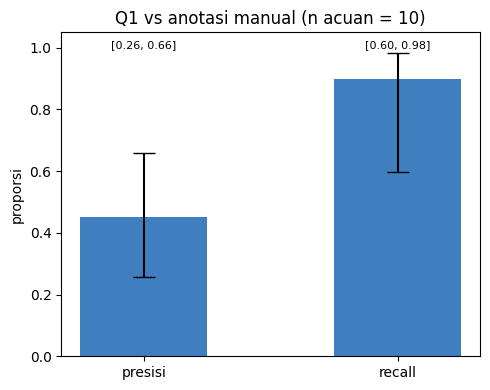

In [10]:
# Visualisasi 3: presisi/recall + CI — hanya digambar kalau vonis judge memang ada
if hasil is None:
    print('dilewati: belum ada vonis judge')
else:
    m = hasil['q1']
    nama = ['presisi', 'recall']
    nilai = [m['presisi'], m['recall']]
    ci = [m['presisi_ci'], m['recall_ci']]
    err = [[v - c[0] for v, c in zip(nilai, ci)], [c[1] - v for v, c in zip(nilai, ci)]]

    plt.figure(figsize=(5, 4))
    plt.bar(nama, nilai, color='#3f7fbf', width=.5)
    plt.errorbar(nama, nilai, yerr=err, fmt='none', ecolor='k', capsize=8, lw=1.5)
    plt.ylim(0, 1.05); plt.ylabel('proporsi')
    plt.title(f"Q1 vs anotasi manual (n acuan = {m['recall_n']})")
    for i, c in enumerate(ci):
        plt.text(i, 1.0, f'[{c[0]:.2f}, {c[1]:.2f}]', ha='center', fontsize=8)
    plt.tight_layout(); plt.show()

## 6. Kenapa Q2 gagal — bias format terukur

Q2 menandai 169 dari 260 baris (65%) sambil tetap meleset dari satu-satunya positif manual.
Menandai dua pertiga dataset lalu luput dari yang sudah diketahui rusak bukan sekadar "n terlalu
kecil untuk diukur" — itu vonis yang tidak membedakan apa pun.

Vonis disilangkan dengan bentuk kunci jawaban. Q1 ikut disilangkan sebagai **kontrol**: ia
dijalankan pada sesi, model, dan backend yang sama persis.

In [11]:
from src.data_validation.judge_quality import _load_progress

if hasil is None:
    print('dilewati: belum ada vonis judge')
else:
    q1_vonis = cal.vonis_ke_posisi(sampel, _load_progress(prog_q1), 'Q1')
    q2_vonis = cal.vonis_ke_posisi(sampel, _load_progress(prog_q2), 'Q2')
    silang_q2 = cal.silang_bentuk_jawaban(sampel, q2_vonis)
    silang_q1 = cal.silang_bentuk_jawaban(sampel, q1_vonis)

    print(cal.cetak_silang(silang_q2, 'Q2 — vonis vs bentuk kunci jawaban'))
    print()
    print(cal.cetak_silang(silang_q1, 'Q1 — KONTROL, run yang sama'))

Q2 — vonis vs bentuk kunci jawaban
kelas jawaban     TIDAK    YA     n  % ditandai
angka_polos          70     7    77         91%
teks_lain            38    26    64         59%
latex                61    58   119         51%
TOTAL               169    91   260         65%

Q1 — KONTROL, run yang sama
kelas jawaban     TIDAK    YA     n  % ditandai
angka_polos           8    69    77         10%
teks_lain             4    60    64          6%
latex                 8   111   119          7%
TOTAL                20   240   260          8%


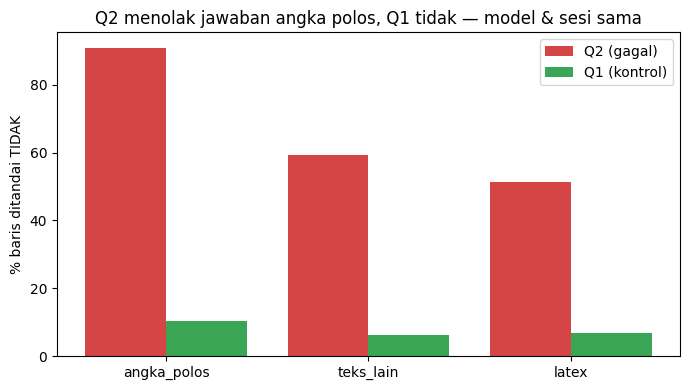

angka polos ditandai TIDAK -> Q2 91%, Q1 10%

Contoh gold ditandai TIDAK oleh Q2 (padahal bentuk ideal jawaban akhir):
   ['2037171', '13', '6.525', '0', '28', '0', '840', '1028']


In [12]:
# Visualisasi 4: bias format Q2 vs Q1
if hasil is None:
    print('dilewati: belum ada vonis judge')
else:
    kelas = ['angka_polos', 'teks_lain', 'latex']
    v_q2 = [silang_q2[k]['persen_ditandai'] for k in kelas]
    v_q1 = [silang_q1[k]['persen_ditandai'] for k in kelas]
    x = range(len(kelas))

    plt.figure(figsize=(7, 4))
    plt.bar([i - .2 for i in x], v_q2, width=.4, color='#d64545', label='Q2 (gagal)')
    plt.bar([i + .2 for i in x], v_q1, width=.4, color='#3aa655', label='Q1 (kontrol)')
    plt.xticks(list(x), kelas); plt.ylabel('% baris ditandai TIDAK')
    plt.title('Q2 menolak jawaban angka polos, Q1 tidak — model & sesi sama')
    plt.legend(); plt.tight_layout(); plt.show()

    print(f"angka polos ditandai TIDAK -> Q2 {v_q2[0]:.0f}%, Q1 {v_q1[0]:.0f}%")
    print()
    print('Contoh gold ditandai TIDAK oleh Q2 (padahal bentuk ideal jawaban akhir):')
    contoh = [str(sampel[p].get('jawaban', '')) for p, ok in q2_vonis.items()
              if not ok and cal.bentuk_jawaban(str(sampel[p].get('jawaban', ''))) == 'angka_polos']
    print('  ', contoh[:8])

### Bacaan

Angka bulat polos adalah bentuk **ideal** jawaban akhir soal matematika. Q2 menolak 91% di
antaranya sambil meloloskan separuh yang berbaju LaTeX — ia menilai **penampilan, bukan tipe**,
padahal `Q2_PROMPT` menyuruh sebaliknya secara eksplisit: *"Anda TIDAK perlu menghitung atau
memastikan nilainya benar — cukup nilai bentuk dan tipenya."*

**Kontrol Q1 mempersempit tersangka.** Q1 rata di ketiga kelas (10% / 6% / 7%) pada sesi, model,
dan backend yang sama. Jadi penyebabnya bukan sesuatu yang berlaku global — bukan decoding, bukan
parser vonis, dan kecil kemungkinan chat template. Yang tersisa: tugas Q2 itu sendiri di luar
kemampuan judge 7B. Uji pemastiannya ada di sel 8 notebook Kaggle.

**Akibat praktis:** Q2 dimatikan, tidak dipakai men-drop maupun mengisi antrean review.
Tujuan aslinya (kunci berupa huruf pilihan ganda) sudah dikerjakan Tahap A regex — 278
`jawaban_bare_letter` tertangkap deterministik, nol GPU.

## 7. Batas sahih — wajib ikut dikutip

1. **Q1 hanya punya 10 positif kuat.** Interval Wilson 95% recall lebarnya 28–53 poin persen
   (sel 4 menggambarnya). Kutip intervalnya, jangan titik estimasinya.
2. **Q2 hanya punya 1 positif pasti (+2 ragu).** Tidak cukup untuk angka apa pun. Modul
   menandainya `TIDAK SAHIH` dan laporan menolak menyebutnya sebagai performa. Perlu anotasi Q2
   tambahan sebelum klaim apa pun tentang Q2.
3. **Baris tak-ditandai = label lemah.** Anotasi manual menyasar baris rusak, bukan memverifikasi
   260 baris satu per satu. "Tidak ditandai" berarti "tampak wajar saat disapu", bukan
   "terverifikasi benar". Akibatnya false-positive yang terhitung adalah **batas atas**, dan
   presisi yang dilaporkan adalah **batas bawah**.
4. **Recall judge bukan recall filter.** Tahap A sudah membuang sebagian baris rusak sebelum
   judge melihatnya (sel 3). Performa filter utuh = tahap A + judge, bukan judge saja.